# Data Initialization


In [18]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

raw_df = pd.read_csv('weekly_player_stats_offense.csv')
rng = np.random.RandomState(seed=67)

In [19]:
# Holden: initialize labels of features to be used or excluded by model
categorical_features = set([])
real_val_features = set([])
features_dropped = set([]) # remove from lists of kept features
metadata_features = set(['player_id', 'season', 'week'])
target_labels = set(['target_fp_ppr_avg'])

for col in raw_df.columns :
    if pd.api.types.is_numeric_dtype(raw_df[col]) :
        real_val_features.add(col)
    else :
        categorical_features.add(col)
        

In [20]:
# feature + target engineering for RNN
window = 3 # Number of weeks used to formulate rolling averages
raw_df = raw_df.sort_values(['player_id', 'season', 'week']) 
raw_df['target_fp_ppr_avg'] = (
    raw_df.groupby(['player_id', 'season'])['fantasy_points_ppr']
    .transform(lambda x : x.shift(-1).rolling(window=window, min_periods=1).mean())
)


In [21]:
# generate a dataframe to measure feature usability 
rv_stats = []
for col in raw_df[list(real_val_features)].columns: 
    s = raw_df[col]
    t = raw_df['target_fp_ppr_avg']

    mask = s.notna() & t.notna()
    s = s[mask]
    t = t[mask]

    non_nan = mask.mean()
    non_zero = (s != 0).mean()
    std = s.std()

    if std > 0 and t.std() > 0 :
        corr = s.corr(t)
    else :
        corr = np.nan

    rv_stats.append({
        "feature": col,
        "frac_non_nan": non_nan,
        "frac_non_zero": non_zero,
        "std": std,
        "corr_with_target": corr,
        "abs_corr": abs(corr) if pd.notna(corr) else np.nan,
    })

feature_stats = pd.DataFrame(rv_stats) 

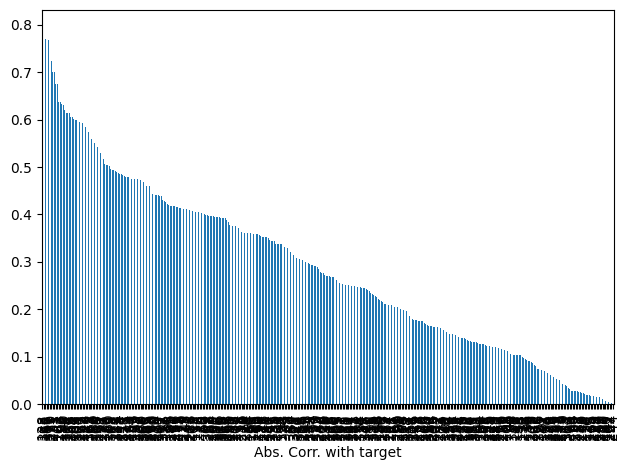

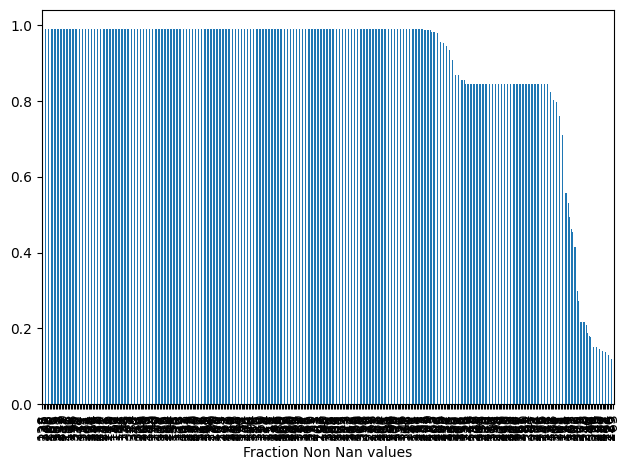

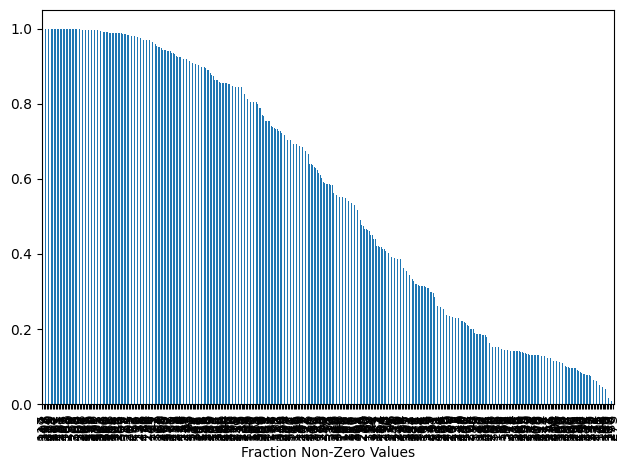

,frac_non_nan,frac_non_zero,std,corr_with_target,abs_corr
count,385.000000,385.000000,385.000000,385.000000,385.000000
mean,0.895754,0.564829,106.974790,0.274875,0.288476
std,0.212271,0.345741,494.859215,0.203015,0.183120
min,0.090484,0.002755,0.027861,-0.405899,0.000807
25%,0.845264,0.201344,0.713804,0.126713,0.132645
50%,0.990738,0.586527,4.010031,0.268201,0.270244
75%,0.990738,0.919430,21.624675,0.411219,0.411219
max,0.990738,1.000000,6048.635106,0.791639,0.791639


In [22]:

feature_stats = feature_stats.sort_values('abs_corr', ascending=False)
feature_stats['abs_corr'].plot(kind='bar')
plt.xlabel("Abs. Corr. with target")
plt.tight_layout()
plt.show()

feature_stats = feature_stats.sort_values('frac_non_nan', ascending=False)
feature_stats['frac_non_nan'].plot(kind='bar')
plt.xlabel('Fraction Non Nan values')
plt.tight_layout()
plt.show()

feature_stats = feature_stats.sort_values('frac_non_zero', ascending=False)
feature_stats['frac_non_zero'].plot(kind='bar')
plt.xlabel("Fraction Non-Zero Values")
plt.tight_layout()
plt.show()
feature_stats.describe()


In [23]:
# cut off any features that are in the bottom 25% of 
# any of the relevance/usability metrics
abs_corr_thresh = feature_stats['abs_corr'].quantile(.25)
non_nan_thresh = feature_stats['frac_non_nan'].quantile(.25)
non_zero_thresh= feature_stats['frac_non_zero'].quantile(.25)

keep_mask = (
    (feature_stats['abs_corr'] >= abs_corr_thresh) &
    (feature_stats['frac_non_nan'] >= non_nan_thresh) &
    (feature_stats['frac_non_zero'] >= non_zero_thresh)
)
keep = feature_stats[keep_mask]['feature'].tolist()
real_val_features.intersection_update(keep)

print(len(real_val_features))


193


In [24]:
from sklearn.preprocessing import OneHotEncoder,  StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ensure feature lists are cohesive
for label in features_dropped :
    if label in categorical_features :
        categorical_features.remove(label)
    elif label in real_val_features :
        real_val_features.remove(label)

#real_val_features.difference_update(target_labels) # take potential targets out of features processed by pipeline

# convert to lists so we can stop typcasting 
real_val_features = list(real_val_features) 
categorical_features = list(categorical_features)
target_labels = list(target_labels)
features_dropped = list(features_dropped)


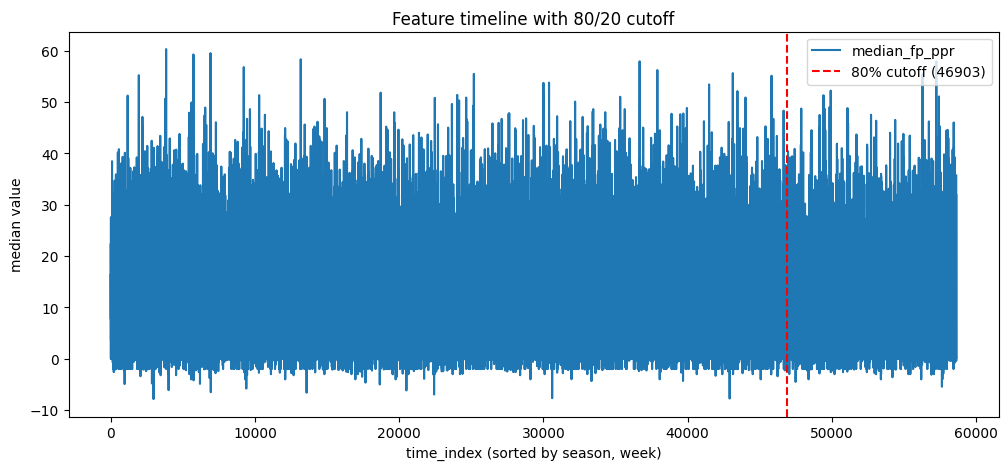

In [25]:

#clean dataframe without features exceeding missing value threshold
clean_df = raw_df.drop(list(features_dropped), axis=1).copy()
clean_df['time_key'] = list(zip(clean_df['season'], clean_df['week']))

clean_df = clean_df.sort_values(['season', 'week']).reset_index(drop=True)
clean_df['time_index'] = np.arange(len(clean_df))
clean_df = clean_df.drop(columns='time_key')

# compute 80% cutoff index (floor so train < cutoff)
cutoff = int(np.floor(len(clean_df) * 0.8))

# aggregate medians per time_index to reduce noise (optional)
agg = clean_df.groupby('time_index').agg(
    fantasy_points_ppr_med=('fantasy_points_ppr','median'),
).reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=agg, x='time_index', y='fantasy_points_ppr_med', label='median_fp_ppr')
plt.xlabel('time_index (sorted by season, week)')
plt.ylabel('median value')
plt.title('Feature timeline with 80/20 cutoff')
plt.axvline(cutoff, color='red', linestyle='--', label=f'80% cutoff ({cutoff})')
plt.legend()
plt.show()

# This code block needs to be moved below next code block (the one with the pipelines defined)
# It would make the most sense to implement this in a function (redefining it not in terms of the clean_df, but in terms of an inputted df)
# This could mean that we need to change the cutoff logic or move it to a different part of the process

# Create train/test using that cutoff
train = clean_df[clean_df['time_index'] < cutoff].drop(columns='time_index')
test = clean_df[clean_df['time_index'] >= cutoff].drop(columns='time_index')

X = clean_df.drop(columns=['fantasy_points_ppr'] + categorical_features)   # features
y = clean_df['fantasy_points_ppr']

tscv = TimeSeriesSplit(n_splits=5)  # or another number of folds
for fold, (train_idx, test_idx) in enumerate(tscv.split(clean_df['time_index'])):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    # train model on X_train, y_train and evaluate on X_test, y_test

In [26]:

#sort real value features by estimated distribution type
rv_split_std = []
rv_split_skewed = []
rv_split_few = []
for feature in real_val_features :
    column = clean_df[feature]
    unique_vals = column.nunique(dropna=True)

    if unique_vals <= 2 :
        rv_split_few.append(feature)
    else :
        skew = column.skew(skipna=True)
        if abs(skew) > 1 :
            rv_split_skewed.append(feature)
        else :
            rv_split_std.append(feature)

#data preprocessing pipelines
#each distribution gets the appropriate scaler 
#current system expects most values to be skewed 
#   - we may be able to improve our estimation and normalization

# TODO 
# add pipeline for time sorting whole dataframe 
# create pipeline / function to designate past fantasy points as a feature 
# use THIS WEEK to predict NEXT WEEK 
# 
std_pipline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

skewed_pipline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

no_scale_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')) 
])

categorical_pipeline = Pipeline(steps=[
    ('OHE', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(transformers=[
    ('norm_rv', std_pipline, rv_split_std),
    ('skewed_rv', skewed_pipline, rv_split_skewed),
    ('few_rv', no_scale_pipeline, rv_split_few),
    ('categorical', categorical_pipeline, categorical_features)
    ])


In [ ]:
import torch
from torch.utils.data import Dataset

class FantasyDataset(Dataset) : 
    def __init__(self, df, features, target, transformer=preprocess, train=True) :
        X = df[features]
        y = df[target]

        if train : 
            X = transformer.fit_transform(X)
        else :
            X = transformer.transform(X)

        self.X = torch.tensor(X.to_numpy())
        self.y = torch.tensor(y.to_numpy())

    def __len__(self) :
        return len(self.X)
    
    def __getitem__(self, idx) : 
        return self.X[idx] , self.y[idx]

# Everything below this point should be model implementation 
## use defined dataframe and preprocessing functions for Builing better model arhcitecture
## Once Time split, feature-target consolidation, and other related preprocessing steps are ready, datasets can be adjusted accordingly

In [28]:
# Connor: Code implementation of a Random Forest model that can predict fantasy points based on player stats
# Holden: heavily refined model implementation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
	
def train_and_evaluate_model(position_df, position_name) :
	
	X = position_df.drop(columns=target_labels)
	y = position_df['fantasy_points_ppr']
	# TODO 
	# Implement Time sorting pipleine/function
	# Replace standard train test split to split according to time index
	
	X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=.2, random_state=rng)
	
	X_train = preprocess.fit_transform(X_train)
	X_test = preprocess.transform(X_test)

	model = RandomForestRegressor(n_estimators=100, random_state=rng, n_jobs=-1)
	model.fit(X_train, y_train)
	
	y_pred = model.predict(X_test)
	
	mse = mean_squared_error(y_test, y_pred)
	r2 = r2_score(y_test, y_pred)
	
	print(f"Position: {position_name}")
	print(f"Mean Squared Error: {mse}")
	print(f"R^2 Score: {r2}\n")


In [29]:

# create seperate datasets for each position
relevant_positions = ['QB', 'RB', 'WR', 'TE']
filtered = clean_df[clean_df['position'].isin(relevant_positions)]
pos_filtered_dfs = {pos : pos_df for pos, pos_df in filtered.groupby('position')}

for position in relevant_positions :
    train_and_evaluate_model(pos_filtered_dfs[position], position)
    



Position: QB
Mean Squared Error: 0.004934942581486297
R^2 Score: 0.9999591856871025

Position: RB
Mean Squared Error: 0.0009283756962024931
R^2 Score: 0.9999855842277116

Position: WR
Mean Squared Error: 0.0005800323673380896
R^2 Score: 0.9999906820920881

Position: TE
Mean Squared Error: 0.0022696251158870638
R^2 Score: 0.9999395481027716



In [30]:
train_and_evaluate_model(clean_df, 'ALL')

Position: ALL
Mean Squared Error: 0.0009624118881118799
R^2 Score: 0.9999872913011832

